In [2]:
import pandas as pd

df = pd.read_csv('../data/churn.csv')
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())
print(df['Churn'].value_counts())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


In [3]:
df = pd.read_csv('../data/churn.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nNull values:\n", df.isnull().sum())
print("\nTarget distribution:\n", df['Churn'].value_counts())
df.head()

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
 customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Null values:
 customerID       

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Drop ID column
df.drop(columns=['customerID'], inplace=True)

# Fix TotalCharges (has spaces for new customers with 0 tenure)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)  # drops ~11 rows with blank TotalCharges

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Clean shape:", df.shape)
print("Nulls remaining:", df.isnull().sum().sum())
print("Churn balance:\n", df['Churn'].value_counts())

Clean shape: (7032, 20)
Nulls remaining: 0
Churn balance:
 Churn
0    5163
1    1869
Name: count, dtype: int64


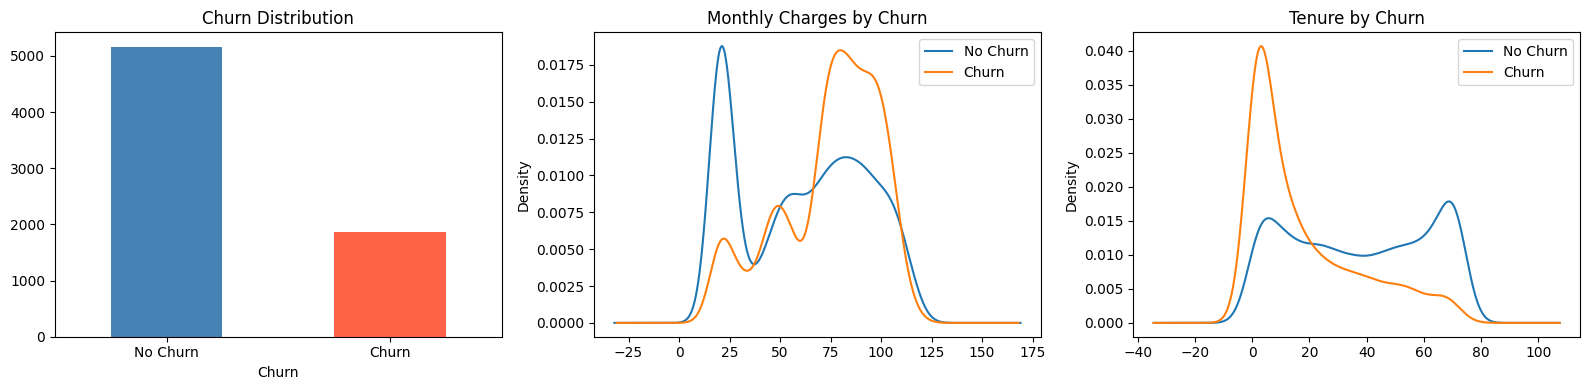

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Churn distribution
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Churn Distribution')
axes[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)

# Monthly Charges by Churn
df.groupby('Churn')['MonthlyCharges'].plot(kind='kde', ax=axes[1], legend=True)
axes[1].set_title('Monthly Charges by Churn')
axes[1].legend(['No Churn', 'Churn'])

# Tenure by Churn
df.groupby('Churn')['tenure'].plot(kind='kde', ax=axes[2], legend=True)
axes[2].set_title('Tenure by Churn')
axes[2].legend(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

In [6]:
# Binary yes/no columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
yes_no_cols = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Map Yes/No to 1/0
for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Map gender
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# For columns with 'No internet service' / 'No phone service' — treat as 'No'
for col in yes_no_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 
                            'No internet service': 0, 
                            'No phone service': 0})

# One-hot encode remaining categoricals
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'], 
                    drop_first=True)

print("Final shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Final shape: (7032, 24)
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


In [7]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print("Training size after SMOTE:", X_train_res.shape)
print("Class balance after SMOTE:\n", pd.Series(y_train_res).value_counts())

Training size after SMOTE: (8260, 23)
Class balance after SMOTE:
 Churn
0    4130
1    4130
Name: count, dtype: int64


In [8]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])
    results[name] = {'Accuracy': round(acc, 4), 'ROC-AUC': round(auc, 4)}
    print(f"\n{name}:")
    print(f"  Accuracy: {acc:.4f} | AUC: {auc:.4f}")

pd.DataFrame(results).T


Random Forest:
  Accuracy: 0.7647 | AUC: 0.8057

Gradient Boosting:
  Accuracy: 0.7640 | AUC: 0.8191

XGBoost:
  Accuracy: 0.7647 | AUC: 0.8002


,Accuracy,ROC-AUC
Random Forest,0.7647,0.8057
Gradient Boosting,0.7640,0.8191
XGBoost,0.7647,0.8002


In [9]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

gb = GradientBoostingClassifier(random_state=42)
grid = GridSearchCV(gb, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
grid.fit(X_train_res, y_train_res)

print("Best Params:", grid.best_params_)
print("Best CV AUC:", round(grid.best_score_, 4))
best_model = grid.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV AUC: 0.9257


Final Accuracy: 0.7591
Final AUC: 0.8087

Classification Report:
               precision    recall  f1-score   support

    No Churn       0.85      0.81      0.83      1033
       Churn       0.54      0.61      0.57       374

    accuracy                           0.76      1407
   macro avg       0.70      0.71      0.70      1407
weighted avg       0.77      0.76      0.76      1407



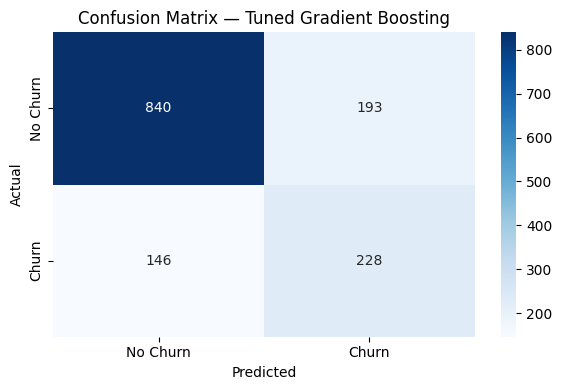

In [10]:
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

print("Final Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Final AUC:", round(roc_auc_score(y_test, y_prob), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred, 
                                    target_names=['No Churn', 'Churn']))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix — Tuned Gradient Boosting')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

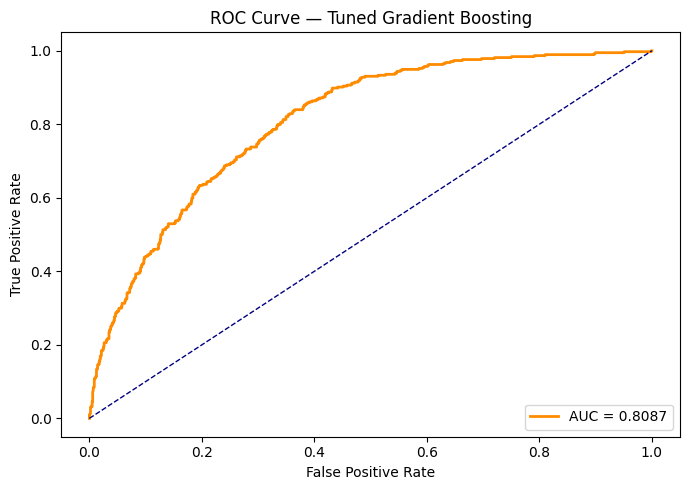

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Tuned Gradient Boosting')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

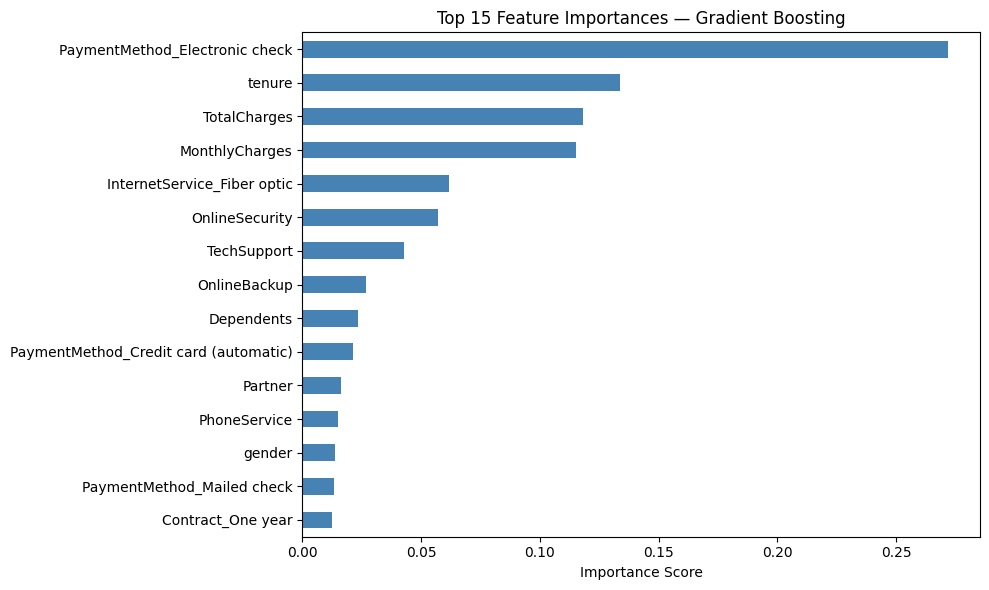


Top 5 churn drivers:
PaymentMethod_Electronic check    0.271801
tenure                            0.133809
TotalCharges                      0.118114
MonthlyCharges                    0.115201
InternetService_Fiber optic       0.061844
dtype: float64


In [12]:
feature_names = X.columns.tolist()
feat_imp = pd.Series(best_model.feature_importances_, index=feature_names)

plt.figure(figsize=(10, 6))
feat_imp.nlargest(15).sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importances — Gradient Boosting')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 churn drivers:")
print(feat_imp.nlargest(5))

In [13]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/gb_churn_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("Model saved to ../models/")
print("Files:", os.listdir('../models/'))

Model saved to ../models/
Files: ['scaler.pkl', 'gb_churn_model.pkl']
